# 24 -- Standardised model out of domain, and sampler comparison

Two inference-only experiments on existing checkpoints. No training.

**Part A -- standardised checkpoint (from `19`) on unseen dates and Cambridge Bay.**
Section 5.2.1 of the dissertation leaves one question open: is the
generalisation collapse caused by the raw-dB *offset* between passes (which
standardisation removes) or by the radar carrying no roughness signal (which
nothing removes)? The standardised model has never been evaluated out of
domain. Same protocol as `08` / `13`: same 25 unseen-date patches, same
400-patch Cambridge Bay subsample, inputs standardised with the **training**
statistics saved by `19`.

**Part B -- DDIM vs PLMS vs DDPM on the real-attribute checkpoint (from `09`).**
The reference study selected PLMS; this study used DDIM throughout. All three
samplers in Tessa's `sampling.py` run the full 1000 steps, so cost is the
same. Full 255-patch validation set, batched. Optionally repeated on the
standardised checkpoint.

Outputs go to `s1_training_outputs/` with the names printed at the end.

In [1]:
import os, sys, json, random, datetime as dt, time
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

assert torch.cuda.is_available(), 'CUDA is required.'
DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True
print('GPU:', torch.cuda.get_device_name(0))

GPU: NVIDIA GeForce RTX 4090


In [2]:
WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
TESSA_REPO = WORKING_REPO / 'tessa_baseline'
CHECKPOINT_DIR = WORKING_REPO / 'checkpoints'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'

CKPT = {
    'realattrs':    CHECKPOINT_DIR / 's1_tuk_pcrtc_realattrs_spatialsplit_unet_best.pth',              # 09
    'standardised': CHECKPOINT_DIR / 's1_tuk_pcrtc_realattrs_spatialsplit_standardised_unet_best.pth', # 19
}
STATS_PATH = OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_standardised_norm_stats.json'               # 19, training split only

TUK_S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
TUK_LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
TUK_SURVEY_DATE = dt.date(2024, 4, 16)
UNSEEN_DIR = WORKING_REPO / 'raw_data' / 'tuk_unseen_date_test'      # t0/t1/t2.tif written by 08
UNSEEN_DATES = [dt.date(2025, 3, 25), dt.date(2025, 3, 27), dt.date(2025, 4, 6)]

CB_S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_cambridge_pcrtc'
CB_LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_cambridge_extracted' / 'lidar_patches_cambridge'
CB_SURVEY_DATE = dt.date(2024, 4, 18)

CONTEXT_K = 3
TARGET_HW = (256, 256)
TIMESTEPS = 1000
VAL_FRACTION = 0.15
SEED = 42
NOISE_SCHEDULE = 'linear'
ATTENTION_VARIANT = 'default'
BLOCK_SIZE_M, BUFFER_M = 1024.0, 150.0
BATCH_SIZE = 8

# Part A
N_UNSEEN = 25          # 08's sample, seed SEED+2
N_CB = 400             # 13's subsample, seed 42
RUN_PART_A = True

# Part B
RUN_PART_B = True
SAMPLERS = ['ddim', 'plms', 'ddpm']
CKPTS_FOR_SAMPLERS = ['realattrs', 'standardised']   # drop 'standardised' to halve Part B

for k, p in CKPT.items(): assert p.exists(), f'missing checkpoint {p}'
assert STATS_PATH.exists(), f'missing {STATS_PATH} -- run 19 first'
NORM = json.load(open(STATS_PATH))
NORM_STATS = (np.array(NORM['mean'], dtype=np.float32), np.array(NORM['std'], dtype=np.float32))
print('training-split stats: VV mean %.2f sd %.2f | VH mean %.2f sd %.2f' % (NORM_STATS[0][0], NORM_STATS[1][0], NORM_STATS[0][1], NORM_STATS[1][1]))

training-split stats: VV mean -18.17 sd 2.56 | VH mean -24.00 sd 2.60


In [3]:
sys.path.insert(0, str(TESSA_REPO))
from src.model.unet import ConditionalUNet
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddim, p_sample_loop_plms, p_sample_loop_ddpm
from src.utils.recon_metrics import rmse, bias, sigma_error, normal_angle_error, average_jsd_multiscale, log_psd_rmse, zncc

SAMPLER_FN = {'ddim': p_sample_loop_ddim, 'plms': p_sample_loop_plms, 'ddpm': p_sample_loop_ddpm}

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def load_model(name):
    m = ConditionalUNet(in_channels=1, cond_channels=4 * CONTEXT_K, attr_dim=8 * CONTEXT_K, base_channels=128,
                        embed_dim=256, unet_depth=4, attention_variant=ATTENTION_VARIANT, cond_k=CONTEXT_K).to(DEVICE)
    ck = torch.load(CKPT[name], map_location=DEVICE)
    m.load_state_dict(ck['model_state_dict']); m.eval()
    print(f'loaded {name}: epoch {ck.get("epoch")} val_loss {ck.get("val_loss")}')
    return m

scheduler = LinearDiffusionScheduler(TIMESTEPS, device=DEVICE) if NOISE_SCHEDULE == 'linear' else CosineDiffusionScheduler(TIMESTEPS, device=DEVICE)
models = {name: load_model(name) for name in CKPT}

loaded realattrs: epoch 93 val_loss 0.013706092446227558
loaded standardised: epoch 79 val_loss 0.01299282857507933


## Shared helpers (identical preprocessing to 09 / 19 / 08 / 13)

In [4]:
def load_sar_db(path_or_array):
    if isinstance(path_or_array, np.ndarray):
        sar = path_or_array.astype(np.float32)
    else:
        with rasterio.open(path_or_array) as src:
            sar = src.read()[:2].astype(np.float32)
    sar = np.nan_to_num(sar, nan=0.0, posinf=0.0, neginf=0.0)
    return 10.0 * np.log10(np.maximum(sar, 1e-12))

def to_condition(raw_views_db, standardise):
    # raw_views_db: list of K arrays (2, h, w) in dB
    views = []
    for sar in raw_views_db:
        if standardise:
            mean, std = NORM_STATS
            sar = (sar - mean[:, None, None]) / std[:, None, None]
        t = F.interpolate(torch.from_numpy(sar).unsqueeze(0), size=TARGET_HW, mode='bilinear', align_corners=False).squeeze(0)
        views.append(t.repeat(2, 1, 1))
    return torch.cat(views, dim=0).float()

def load_target(lidar_dir, pid):
    with rasterio.open(lidar_dir / f'lidar_patch_{pid}.tif') as src:
        raw = src.read().astype(np.float32)
    target = raw[0]
    mask = (raw[1] > 0.5) if raw.shape[0] > 1 else np.isfinite(target)
    target = np.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0)
    pm = float(target[mask].sum() / max(1, mask.sum()))
    return ((target - pm) * mask).astype(np.float32), mask, pm

def attrs_from_json(s1_path, times, survey_date):
    attrs_list = json.load(open(s1_path / 'attrs.json'))
    vecs = []
    for t in times:
        a = attrs_list[int(t.stem[1:])]
        age = (dt.date.fromisoformat(a['acquisition_date']) - survey_date).days / 30.0 if a.get('acquisition_date') else 0.0
        vecs.append([age, 1.0 if a.get('orbit_direction') == 'ASCENDING' else 0.0, (a.get('relative_orbit_number') or 0) / 175.0, 0, 0, 0, 0, 0])
    return torch.tensor(vecs, dtype=torch.float32).flatten()

class Items(Dataset):
    # items: list of dicts {pid, cond, attrs, target, mask, pm}
    def __init__(self, items): self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        it = self.items[i]
        return {'pid': it['pid'], 's1': it['cond'], 'attrs': it['attrs'],
                'lidar': torch.from_numpy(it['target']).unsqueeze(0), 'mask': torch.from_numpy(it['mask']),
                'patch_mean': torch.tensor(it['pm'])}

def metrics_row(pid, gt_i, pred_i, mask_i):
    gt_valid = gt_i.squeeze()[mask_i].cpu().numpy(); pred_valid = pred_i.squeeze()[mask_i].cpu().numpy()
    return {'patch_id': pid,
            'rmse_m': float(rmse(gt_i, pred_i, mask_i).item()),
            'bias_m': float(bias(gt_i, pred_i, mask_i).item()),
            'sigma_error_pct': float(sigma_error(gt_i, pred_i, mask_i).item()),
            'normal_angle_error_deg': float(normal_angle_error(gt_i, pred_i, mask_i, pixel_size=1.0, degrees=True).item()),
            'jsd': float(average_jsd_multiscale(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
            'psd_rmse': float(log_psd_rmse(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
            'zncc': float(zncc(gt_i, pred_i, mask_i).item()),
            'gt_std_val': float(gt_valid.std()), 'pred_std_val': float(pred_valid.std())}

@torch.no_grad()
def evaluate(model, items, sampler='ddim', tag=''):
    seed_everything(SEED)
    loader = DataLoader(Items(items), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    fn = SAMPLER_FN[sampler]
    rows, t0 = [], time.time()
    for b, batch in enumerate(loader):
        cond = batch['s1'].to(DEVICE); attrs = batch['attrs'].to(DEVICE)
        target = batch['lidar'].to(DEVICE); mask = batch['mask'].to(DEVICE).bool()
        pm = batch['patch_mean'].to(DEVICE).view(-1, 1, 1, 1)
        pred = fn(model, scheduler, target.shape, cond, attrs, DEVICE)
        gt_abs, pred_abs = target + pm, pred + pm
        for i in range(target.shape[0]):
            rows.append(metrics_row(batch['pid'][i], gt_abs[i], pred_abs[i], mask[i]))
        if (b + 1) % 5 == 0: print(f'  [{tag}/{sampler}] {len(rows)}/{len(items)}  {time.time()-t0:.0f}s')
    mean = {k: float(np.nanmean([r[k] for r in rows])) for k in rows[0] if k != 'patch_id'}
    print(f'{tag:<40} {sampler:<5} ZNCC {mean["zncc"]:+.4f}  RMSE {mean["rmse_m"]:.4f}  sig% {mean["sigma_error_pct"]:6.1f}  '
          f'JSD {mean["jsd"]:.4f}  PSD {mean["psd_rmse"]:.4f}  pred/gt {mean["pred_std_val"]:.4f}/{mean["gt_std_val"]:.4f}')
    return {'rows': rows, 'mean': mean}

## Split and patch sets (as in 09 / 08 / 13)

In [5]:
lidar_ids = {p.stem.split('_')[-1] for p in TUK_LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in TUK_S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)

def centroid(pid):
    with rasterio.open(TUK_LIDAR_DIR / f'lidar_patch_{pid}.tif') as src: b = src.bounds
    return ((b.left + b.right) / 2, (b.bottom + b.top) / 2)

blocks, dropped = {}, []
for pid in paired_ids:
    cx, cy = centroid(pid)
    bx, by = int(cx // BLOCK_SIZE_M), int(cy // BLOCK_SIZE_M)
    d = min(cx - bx * BLOCK_SIZE_M, (bx + 1) * BLOCK_SIZE_M - cx, cy - by * BLOCK_SIZE_M, (by + 1) * BLOCK_SIZE_M - cy)
    (dropped if d < BUFFER_M else blocks.setdefault((bx, by), [])).append(pid)
block_ids = list(blocks); random.Random(SEED).shuffle(block_ids)
target_val = int(len(paired_ids) * VAL_FRACTION)
val_ids, n = [], 0
for bid in block_ids:
    if n < target_val: val_ids.extend(blocks[bid]); n += len(blocks[bid])
assert len(val_ids) == 255, f'val={len(val_ids)}, expected 255 -- split does not match 09'
unseen_ids = random.Random(SEED + 2).sample(val_ids, N_UNSEEN)

cb_all = sorted({p.stem.split('_')[-1] for p in CB_LIDAR_DIR.glob('lidar_patch_*.tif')} &
                {p.name.split('_')[-1] for p in CB_S1_DIR.glob('s1_patch_*') if p.is_dir()})
cb_ids = random.Random(42).sample(cb_all, min(N_CB, len(cb_all)))
print(f'val={len(val_ids)}  unseen-date subset={len(unseen_ids)}  CB paired={len(cb_all)} -> using {len(cb_ids)}')

val=255  unseen-date subset=25  CB paired=2101 -> using 400


In [6]:
def tuk_items(pids, standardise):
    out = []
    for pid in pids:
        s1_path = TUK_S1_DIR / f's1_patch_{pid}'
        times = sorted(s1_path.glob('t*.tif'))[:CONTEXT_K]
        tgt, msk, pm = load_target(TUK_LIDAR_DIR, pid)
        out.append({'pid': pid, 'cond': to_condition([load_sar_db(t) for t in times], standardise),
                    'attrs': attrs_from_json(s1_path, times, TUK_SURVEY_DATE), 'target': tgt, 'mask': msk, 'pm': pm})
    return out

def cb_items(pids, standardise):
    out = []
    for pid in pids:
        s1_path = CB_S1_DIR / f's1_patch_{pid}'
        times = sorted(s1_path.glob('t*.tif'))[:CONTEXT_K]
        tgt, msk, pm = load_target(CB_LIDAR_DIR, pid)
        out.append({'pid': pid, 'cond': to_condition([load_sar_db(t) for t in times], standardise),
                    'attrs': attrs_from_json(s1_path, times, CB_SURVEY_DATE), 'target': tgt, 'mask': msk, 'pm': pm})
    return out

# unseen-date scenes saved by 08; orbit metadata from STAC (cheap, no download)
merged_paths = [UNSEEN_DIR / f't{i}.tif' for i in range(CONTEXT_K)]
assert all(p.exists() for p in merged_paths), f'08 outputs missing in {UNSEEN_DIR}'

def unseen_attrs():
    """Orbit direction / relative orbit for the three 2025 scenes.
    Try STAC; if the network or certificate fails, derive them offline from
    the training attrs: Sentinel-1 repeats every 12 days, so a 2025 scene on
    the same orbit as a 2024 scene is an exact multiple of 12 days later."""
    vecs = None
    try:
        import pystac_client, planetary_computer
        from dotenv import load_dotenv; load_dotenv()
        if os.environ.get('PC_SDK_SUBSCRIPTION_KEY'):
            planetary_computer.settings.set_subscription_key(os.environ['PC_SDK_SUBSCRIPTION_KEY'])
        with rasterio.open(merged_paths[0]) as src:
            bbox = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
        cat = pystac_client.Client.open('https://planetarycomputer.microsoft.com/api/stac/v1', modifier=planetary_computer.sign_inplace, timeout=20)
        s, e = UNSEEN_DATES[0] - dt.timedelta(days=1), UNSEEN_DATES[-1] + dt.timedelta(days=1)
        items = {it.datetime.date(): it for it in cat.search(collections=['sentinel-1-rtc'], bbox=bbox, datetime=f'{s.isoformat()}/{e.isoformat()}').items()}
        vecs = []
        for d in UNSEEN_DATES:
            it = items[d]
            vecs.append([(d - TUK_SURVEY_DATE).days / 30.0, 1.0 if it.properties.get('sat:orbit_state') == 'ascending' else 0.0,
                         (it.properties.get('sat:relative_orbit') or 0) / 175.0, 0, 0, 0, 0, 0])
        print('orbit metadata from STAC')
    except Exception as exc:
        print(f'STAC unavailable ({type(exc).__name__}); deriving orbit metadata from training attrs via the 12-day repeat cycle')
        train_attrs = json.load(open(TUK_S1_DIR / f's1_patch_{val_ids[0]}' / 'attrs.json'))
        by_date = {dt.date.fromisoformat(a['acquisition_date']): a for a in train_attrs if a.get('acquisition_date')}
        vecs = []
        for d in UNSEEN_DATES:
            match = next((a for td, a in by_date.items() if (d - td).days % 12 == 0), None)
            if match is None:
                print(f'  {d}: no training scene on the same 12-day cycle; orbit attrs set to 0')
                od, ro = 0.0, 0
            else:
                od, ro = (1.0 if match['orbit_direction'] == 'ASCENDING' else 0.0), (match.get('relative_orbit_number') or 0)
                print(f'  {d}: same cycle as {match["acquisition_date"]} -> {match["orbit_direction"]}, rel. orbit {ro}')
            vecs.append([(d - TUK_SURVEY_DATE).days / 30.0, od, ro / 175.0, 0, 0, 0, 0, 0])
    return torch.tensor(vecs, dtype=torch.float32).flatten()

def unseen_items(pids, standardise, attrs):
    out = []
    for pid in pids:
        with rasterio.open(TUK_LIDAR_DIR / f'lidar_patch_{pid}.tif') as l:
            lb, lcrs, h, w = l.bounds, l.crs, l.height, l.width
        views = []
        for mp in merged_paths:
            with rasterio.open(mp) as src:
                win = from_bounds(*transform_bounds(lcrs, src.crs, *lb, densify_pts=21), transform=src.transform)
                views.append(load_sar_db(src.read(window=win, out_shape=(2, h, w))))
        tgt, msk, pm = load_target(TUK_LIDAR_DIR, pid)
        out.append({'pid': pid, 'cond': to_condition(views, standardise), 'attrs': attrs, 'target': tgt, 'mask': msk, 'pm': pm})
    return out

## Check the 2025 scenes before using them

Three things can be wrong with the files `08` saved: a truncated download
(scene smaller than the AOI), nodata over the patches, or a backscatter
level far from the training distribution. This cell reports all three and
draws each 2025 scene beside the 2024 `t0` of the same patch.

file    date        shape           CRS          nodata/zero %     VV dB mean/sd     VH dB mean/sd
t0.tif  2025-03-25  (1719, 379)     EPSG:32608           0.00%   -20.35/2.59       -27.09/1.98    
t1.tif  2025-03-27  (1719, 379)     EPSG:32608           0.00%   -17.88/2.32       -22.86/1.75    
t2.tif  2025-04-06  (1719, 379)     EPSG:32608           0.00%   -19.95/2.44       -26.96/1.90    
training split: VV -18.17/2.56   VH -24.00/2.60
25/25 unseen-date patches fully covered by all three scenes with <2% bad pixels

SCENES OK


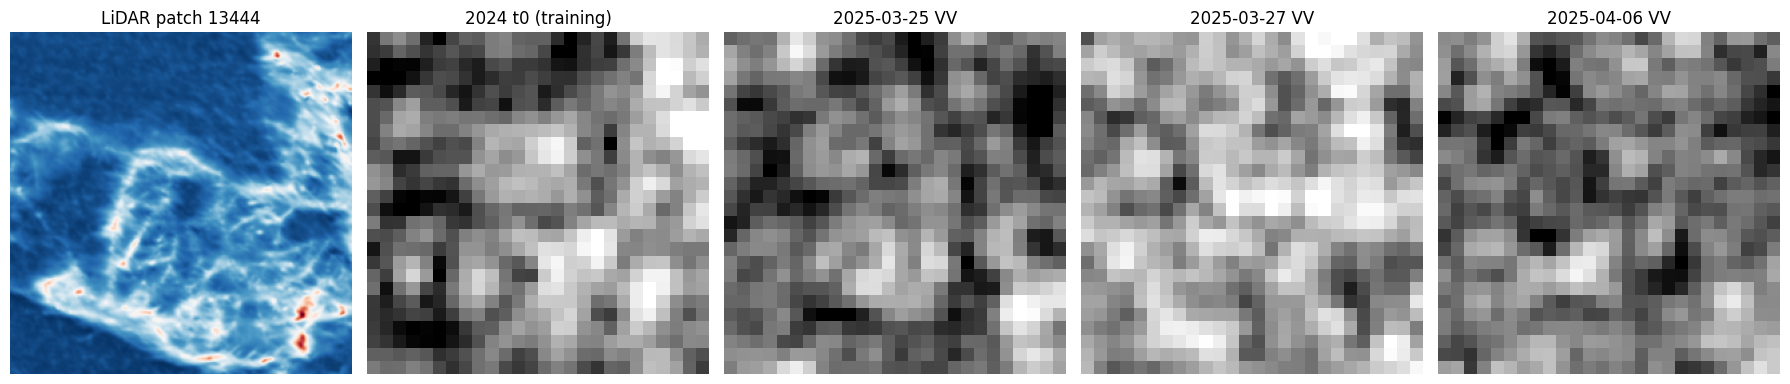

In [7]:
import matplotlib.pyplot as plt
print(f'{"file":<8}{"date":<12}{"shape":<16}{"CRS":<12}{"nodata/zero %":>14}{"VV dB mean/sd":>18}{"VH dB mean/sd":>18}')
scene_ok = True
for i, (mp, d) in enumerate(zip(merged_paths, UNSEEN_DATES)):
    with rasterio.open(mp) as src:
        arr = src.read().astype(np.float32); crs = str(src.crs); bounds = src.bounds
    bad = float(np.mean(~np.isfinite(arr) | (arr <= 0)) * 100)
    db = load_sar_db(arr)
    ok = np.isfinite(arr[0]) & (arr[0] > 0)
    vv, vh = db[0][ok], db[1][ok]
    print(f't{i}.tif  {d.isoformat():<12}{str(arr.shape[1:]):<16}{crs[:11]:<12}{bad:>13.2f}%{vv.mean():>9.2f}/{vv.std():<8.2f}{vh.mean():>9.2f}/{vh.std():<8.2f}')
    if bad > 5 or abs(vv.mean() - NORM_STATS[0][0]) > 6: scene_ok = False
print(f'training split: VV {NORM_STATS[0][0]:.2f}/{NORM_STATS[1][0]:.2f}   VH {NORM_STATS[0][1]:.2f}/{NORM_STATS[1][1]:.2f}')

# every unseen-date patch must be fully inside every scene, with no zero/NaN pixels in its window
uncovered = []
for pid in unseen_ids:
    with rasterio.open(TUK_LIDAR_DIR / f'lidar_patch_{pid}.tif') as l:
        lb, lcrs = l.bounds, l.crs
    for mp in merged_paths:
        with rasterio.open(mp) as src:
            b = transform_bounds(lcrs, src.crs, *lb, densify_pts=21)
            inside = (b[0] >= src.bounds.left and b[2] <= src.bounds.right and b[1] >= src.bounds.bottom and b[3] <= src.bounds.top)
            win = from_bounds(*b, transform=src.transform)
            w = src.read(1, window=win)
            frac_bad = float(np.mean(~np.isfinite(w) | (w <= 0))) if w.size else 1.0
        if not inside or frac_bad > 0.02:
            uncovered.append((pid, mp.name, inside, round(frac_bad, 3)))
print(f'{len(unseen_ids) - len({u[0] for u in uncovered})}/{len(unseen_ids)} unseen-date patches fully covered by all three scenes with <2% bad pixels')
for u in uncovered[:10]: print('  problem:', u)
if uncovered: scene_ok = False
print('\nSCENES OK' if scene_ok else '\nSCENES NEED ATTENTION -- do not run Part A until fixed')

# quick-look: one patch, 2024 t0 vs the three 2025 scenes, same colour scale
pid = unseen_ids[0]
s1_path = TUK_S1_DIR / f's1_patch_{pid}'
ref = load_sar_db(sorted(s1_path.glob('t*.tif'))[0])[0]
with rasterio.open(TUK_LIDAR_DIR / f'lidar_patch_{pid}.tif') as l:
    lb, lcrs, h, w = l.bounds, l.crs, l.height, l.width
    lidar = l.read(1)
panels = [('2024 t0 (training)', ref)]
for mp, d in zip(merged_paths, UNSEEN_DATES):
    with rasterio.open(mp) as src:
        win = from_bounds(*transform_bounds(lcrs, src.crs, *lb, densify_pts=21), transform=src.transform)
        panels.append((f'{d} VV', load_sar_db(src.read(window=win))[0]))
vmin, vmax = np.nanpercentile(ref, 2), np.nanpercentile(ref, 98)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(lidar, cmap='RdBu_r'); axes[0].set_title(f'LiDAR patch {pid}')
for ax, (t, im) in zip(axes[1:], panels):
    ax.imshow(im, cmap='gray', vmin=vmin, vmax=vmax); ax.set_title(t)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## Part A -- standardised checkpoint out of domain

Inputs are standardised with the **training-split** statistics from `19`
(never re-estimated on the test data), exactly as the model saw them in
training. The unstandardised real-attribute rows are re-run alongside for a
same-noise comparison.

In [8]:
results_A = {}
if RUN_PART_A:
    ua = unseen_attrs()
    print('unseen-date age attrs:', [round(float(v), 2) for v in ua.view(CONTEXT_K, 8)[:, 0]])
    sets = {
        'in-region (255)':      lambda st: tuk_items(val_ids, st),
        'unseen dates (25)':    lambda st: unseen_items(unseen_ids, st, ua),
        f'Cambridge Bay ({len(cb_ids)})': lambda st: cb_items(cb_ids, st),
    }
    for name, build in sets.items():
        for ck, st in [('standardised', True), ('realattrs', False)]:
            key = f'{name} | {ck}'
            if name.startswith('in-region') and ck == 'realattrs':
                continue   # already in 09; the standardised in-region row reproduces 19 as a sanity check
            results_A[key] = evaluate(models[ck], build(st), 'ddim', tag=key)
    json.dump({k: v['mean'] for k, v in results_A.items()}, open(OUTPUT_DIR / 's1_pcrtc_standardised_out_of_domain_summary.json', 'w'), indent=2)
    json.dump({k: v['rows'] for k, v in results_A.items()}, open(OUTPUT_DIR / 's1_pcrtc_standardised_out_of_domain_rows.json', 'w'), indent=2)
    print('saved s1_pcrtc_standardised_out_of_domain_{summary,rows}.json')

STAC unavailable (APIError); deriving orbit metadata from training attrs via the 12-day repeat cycle
  2025-03-25: same cycle as 2024-03-18 -> ASCENDING, rel. orbit 108
  2025-03-27: same cycle as 2024-03-20 -> ASCENDING, rel. orbit 137
  2025-04-06: same cycle as 2024-03-18 -> ASCENDING, rel. orbit 108
unseen-date age attrs: [11.43, 11.5, 11.83]
  [in-region (255) | standardised/ddim] 40/255  379s
  [in-region (255) | standardised/ddim] 80/255  757s
  [in-region (255) | standardised/ddim] 120/255  1134s
  [in-region (255) | standardised/ddim] 160/255  1512s
  [in-region (255) | standardised/ddim] 200/255  1889s
  [in-region (255) | standardised/ddim] 240/255  2267s
in-region (255) | standardised           ddim  ZNCC +0.3169  RMSE 0.1726  sig%   32.8  JSD 0.1252  PSD 1.7439  pred/gt 0.1148/0.1721
unseen dates (25) | standardised         ddim  ZNCC -0.0255  RMSE 0.1879  sig%   76.4  JSD 0.5245  PSD 2.3810  pred/gt 0.0359/0.1798
unseen dates (25) | realattrs            ddim  ZNCC -0.0190

In [10]:
partial = {k: v['mean'] for k, v in results_A.items()}
json.dump(partial, open(OUTPUT_DIR / 's1_pcrtc_24_partial_summary.json', 'w'), indent=2)
json.dump({k: v['rows'] for k, v in results_A.items()}, open(OUTPUT_DIR / 's1_pcrtc_24_partial_rows.json', 'w'), indent=2)
if 'results_B' in dir() and results_B:
    json.dump({k: v['rows'] for k, v in results_B.items()}, open(OUTPUT_DIR / 's1_pcrtc_24_partial_B_rows.json', 'w'), indent=2)
print('saved:', list(results_A), list(results_B) if 'results_B' in dir() else [])


saved: ['in-region (255) | standardised', 'unseen dates (25) | standardised', 'unseen dates (25) | realattrs', 'Cambridge Bay (400) | standardised', 'Cambridge Bay (400) | realattrs'] []


## Part B -- sampler comparison on the full validation set

Same checkpoint, same 255 patches, same noise seed; only the sampler changes.
DDIM reproduces the `09` / `19` numbers up to the noise draw.

In [8]:
results_B = {}
if RUN_PART_B:
    for ck in CKPTS_FOR_SAMPLERS:
        items = tuk_items(val_ids, standardise=(ck == 'standardised'))
        for smp in SAMPLERS:
            key = f'{ck} | {smp}'
            results_B[key] = evaluate(models[ck], items, smp, tag=key)
            json.dump(results_B[key]['rows'], open(OUTPUT_DIR / f's1_pcrtc_{ck}_spatialsplit_{smp}_validation_metrics.json', 'w'), indent=2)
    json.dump({k: v['mean'] for k, v in results_B.items()}, open(OUTPUT_DIR / 's1_pcrtc_sampler_comparison_summary.json', 'w'), indent=2)
    print('saved s1_pcrtc_sampler_comparison_summary.json and per-run *_validation_metrics.json')

  [realattrs | ddim/ddim] 40/255  383s
  [realattrs | ddim/ddim] 80/255  761s
  [realattrs | ddim/ddim] 120/255  1139s
  [realattrs | ddim/ddim] 160/255  1517s
  [realattrs | ddim/ddim] 200/255  1896s
  [realattrs | ddim/ddim] 240/255  2274s
realattrs | ddim                         ddim  ZNCC +0.2343  RMSE 0.1947  sig%   22.7  JSD 0.1159  PSD 1.3047  pred/gt 0.1399/0.1721
  [realattrs | plms/plms] 40/255  378s
  [realattrs | plms/plms] 80/255  756s
  [realattrs | plms/plms] 120/255  1135s
  [realattrs | plms/plms] 160/255  1513s
  [realattrs | plms/plms] 200/255  1891s
  [realattrs | plms/plms] 240/255  2269s
realattrs | plms                         plms  ZNCC +0.3063  RMSE 0.1746  sig%   30.5  JSD 0.1461  PSD 1.5058  pred/gt 0.1172/0.1721
  [realattrs | ddpm/ddpm] 40/255  378s
  [realattrs | ddpm/ddpm] 80/255  756s
  [realattrs | ddpm/ddpm] 120/255  1135s
  [realattrs | ddpm/ddpm] 160/255  1513s
  [realattrs | ddpm/ddpm] 200/255  1891s
  [realattrs | ddpm/ddpm] 240/255  2269s
realattr

## Summary

In [10]:
import json, numpy as np
S = json.load(open(OUTPUT_DIR / 's1_pcrtc_sampler_comparison_summary.json'))
A = json.load(open(OUTPUT_DIR / 's1_pcrtc_standardised_out_of_domain_summary.json'))
row = lambda k, m: f"{k:<34} {m['zncc']:+.4f}  {m['rmse_m']:.4f}  {m['sigma_error_pct']:6.1f}  {m['jsd']:.4f}  {m['psd_rmse']:.4f}  {m['pred_std_val']:.4f}/{m['gt_std_val']:.4f}  NAE {m['normal_angle_error_deg']:.3f}"
print('PART A'); [print(row(k, m)) for k, m in A.items()]
print('\nPART B'); [print(row(k, m)) for k, m in S.items()]
print()
for ck in ['realattrs', 'standardised']:
    base = {r['patch_id']: r['zncc'] for r in json.load(open(OUTPUT_DIR / f's1_pcrtc_{ck}_spatialsplit_ddim_validation_metrics.json'))}
    for smp in ['plms', 'ddpm']:
        rows = json.load(open(OUTPUT_DIR / f's1_pcrtc_{ck}_spatialsplit_{smp}_validation_metrics.json'))
        d = np.array([r['zncc'] - base[r['patch_id']] for r in rows])
        print(f'{ck}: ZNCC({smp}) - ZNCC(ddim) = {d.mean():+.4f} +/- {d.std(ddof=1)/np.sqrt(len(d)):.4f}  (paired, n={len(d)})')


PART A
in-region (255) | standardised     +0.3169  0.1726    32.8  0.1252  1.7439  0.1148/0.1721  NAE 1.773
unseen dates (25) | standardised   -0.0255  0.1879    76.4  0.5245  2.3810  0.0359/0.1798  NAE 1.638
unseen dates (25) | realattrs      -0.0190  0.2081    47.0  0.2773  1.3089  0.0929/0.1798  NAE 1.896
Cambridge Bay (400) | standardised +0.0035  0.1432   100.3  0.2414  1.2863  0.1039/0.0834  NAE 1.113
Cambridge Bay (400) | realattrs    -0.0041  0.3387   496.3  0.5567  1.5642  0.3151/0.0834  NAE 2.458

PART B
realattrs | ddim                   +0.2343  0.1947    22.7  0.1159  1.3047  0.1399/0.1721  NAE 1.993
realattrs | plms                   +0.3063  0.1746    30.5  0.1461  1.5058  0.1172/0.1721  NAE 1.790
realattrs | ddpm                   +0.2298  0.1915    27.1  0.1272  1.3654  0.1300/0.1721  NAE 1.948
standardised | ddim                +0.3169  0.1726    32.8  0.1252  1.7451  0.1147/0.1721  NAE 1.773
standardised | plms                +0.3700  0.1632    37.8  0.1328  1.9660  

## How to read

**Part A.** Compare `unseen dates | standardised` and `Cambridge Bay | standardised`
against their `realattrs` rows (same patches, same noise).
- Both still ≈ 0 → the dB offset is not the cause; the saturation reading
  stands alone. §5.2.1's "cannot be separated" becomes "separated: it is the
  radar". One sentence in §4.5, one in §5.2.1, delete the future-work item.
- Recovery toward the in-region value → the offset *was* the cause, and
  standardisation is a real fix for cross-date use. That is a finding and
  changes §5.2, §5.3 and the Conclusion.

**Part B.** Paired differences vs DDIM are the statistic to quote. The
reference's PLMS-over-DDIM gain was ≈ +0.06. If PLMS ≥ DDIM + 0.03 here, the
"DDIM not PLMS" departure in §5.6 becomes a quantified one and the benchmark
comparison in §4.8 gains a like-for-like PLMS row.